# Importing Libraries

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

#  Loading model 

In [19]:
model= tf.keras.models.load_model('trained_model.h5')
print(model)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

# Visualization single Image og Test set

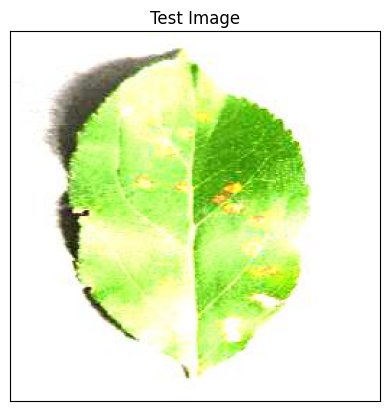

In [ ]:
import cv2
import matplotlib.pyplot as plt
image_path="test/test/AppleCedarRust1.JPG" 
# reading image
img=cv2.imread(image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #to convert BGR image to RGB
# Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()


# Testing Model

In [ ]:
image=tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr=tf.keras.preprocessing.image.img_to_array(image)
input_arr=np.array([input_arr]) #convert single image to a batch
print(input_arr.shape) 

(1, 128, 128, 3)


In [23]:
prediction=model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 357ms/step


(array([[6.50898693e-12, 5.95833129e-14, 1.00000000e+00, 7.57141322e-15,
         4.17000670e-11, 7.84702259e-09, 3.86136116e-17, 1.33392811e-11,
         1.78656547e-16, 7.39370824e-15, 1.47386032e-17, 5.75815784e-12,
         8.59899717e-15, 4.58794919e-16, 6.28291364e-14, 5.43189679e-13,
         2.59278397e-11, 5.50626472e-12, 3.66466926e-12, 3.30626304e-10,
         1.12954480e-15, 4.52511970e-14, 2.46308009e-12, 3.41118561e-12,
         4.27003258e-16, 2.36728020e-12, 6.16653792e-15, 2.53785725e-15,
         5.87842330e-10, 7.86604948e-10, 2.34216095e-08, 1.31906760e-13,
         2.72084850e-12, 3.28251546e-15, 4.68635042e-09, 3.39826466e-11,
         1.19332174e-11, 6.96919911e-10]], dtype=float32),
 (1, 38))

In [7]:
result_index= np.argmax(prediction)
result_index

2

In [8]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [15]:
result_index

2

In [ ]:
# Fertilizer suggestions dictionary
fertilizer_recommendations = {
    'Apple___Apple_scab': "Use nitrogen-rich fertilizer and apply fungicide sprays.",
    'Apple___Black_rot': "Apply balanced NPK and copper-based fungicide.",
    'Apple___Cedar_apple_rust': "Use sulfur-based fungicide and potassium-rich fertilizer.",
    'Apple___healthy': "Maintain balanced NPK and organic compost.",
    'Blueberry___healthy': "Use acidic fertilizer with ammonium sulfate.",
    'Cherry_(including_sour)___Powdery_mildew': "Apply sulfur fungicide and potassium nitrate.",
    'Cherry_(including_sour)___healthy': "Use compost and balanced micronutrients.",
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': "Apply nitrogen and foliar fungicide.",
    'Corn_(maize)___Common_rust_': "Use phosphorus-rich fertilizer and rust-resistant varieties.",
    'Corn_(maize)___Northern_Leaf_Blight': "Apply potassium and foliar sprays.",
    'Corn_(maize)___healthy': "Use urea and balanced micronutrients.",
    'Grape___Black_rot': "Apply copper fungicide and potassium sulfate.",
    'Grape___Esca_(Black_Measles)': "Use organic compost and avoid overwatering.",
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': "Apply foliar sprays and magnesium-rich fertilizer.",
    'Grape___healthy': "Use balanced NPK and organic mulch.",
    'Orange___Haunglongbing_(Citrus_greening)': "Apply zinc and manganese foliar sprays.",
    'Peach___Bacterial_spot': "Use copper fungicide and nitrogen-rich fertilizer.",
    'Peach___healthy': "Apply compost and calcium nitrate.",
    'Pepper,_bell___Bacterial_spot': "Use copper sprays and nitrogen fertilizer.",
    'Pepper,_bell___healthy': "Apply balanced NPK and organic compost.",
    'Potato___Early_blight': "Use phosphorus-rich fertilizer and chlorothalonil fungicide.",
    'Potato___Late_blight': "Apply metalaxyl fungicide and potassium nitrate.",
    'Potato___healthy': "Use compost and balanced NPK.",
    'Raspberry___healthy': "Apply compost and potassium sulfate.",
    'Soybean___healthy': "Use nitrogen-fixing inoculants and potassium fertilizer.",
    'Squash___Powdery_mildew': "Apply sulfur fungicide and compost tea.",
    'Strawberry___Leaf_scorch': "Use potassium-rich fertilizer and copper sprays.",
    'Strawberry___healthy': "Apply compost and micronutrients.",
    'Tomato___Bacterial_spot': "Use copper fungicide and nitrogen fertilizer.",
    'Tomato___Early_blight': "Apply phosphorus-rich fertilizer and fungicide.",
    'Tomato___Late_blight': "Use metalaxyl fungicide and potassium nitrate.",
    'Tomato___Leaf_Mold': "Apply calcium nitrate and improve airflow.",
    'Tomato___Septoria_leaf_spot': "Use potassium-rich fertilizer and chlorothalonil.",
    'Tomato___Spider_mites Two-spotted_spider_mite': "Apply neem oil and micronutrient mix.",
    'Tomato___Target_Spot': "Use magnesium-rich foliar spray and fungicide.",
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': "Apply seaweed extract and potassium sulfate.",
    'Tomato___Tomato_mosaic_virus': "Use compost and avoid nitrogen overdose.",
    'Tomato___healthy': "Maintain balanced NPK and regular composting."
}


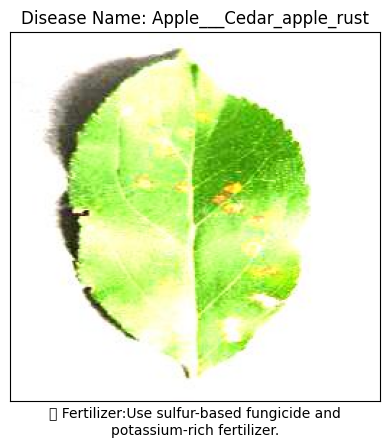

Predicted Disease: Apple___Cedar_apple_rust
Fertilizer Recommendation: Use sulfur-based fungicide and potassium-rich fertilizer.


In [37]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import textwrap

#Displaying Result of disease prediction
model_prediction = class_name[result_index]
fertilizer_suggestion = fertilizer_recommendations.get(model_prediction, "No recommendation available.")
wrapped_suggestion = textwrap.fill(fertilizer_suggestion, width=40)


plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xlabel(f"💡 Fertilizer:{wrapped_suggestion}")
plt.xticks([])
plt.yticks([])
plt.show()

# Optional: print separately
print("Predicted Disease:", model_prediction)
print("Fertilizer Recommendation:", fertilizer_suggestion)

In [38]:
print("Predicted Disease:", model_prediction)
print("Fertilizer Recommendation:", fertilizer_suggestion)

Predicted Disease: Apple___Cedar_apple_rust
Fertilizer Recommendation: Use sulfur-based fungicide and potassium-rich fertilizer.
